# Plan complet notebook : Livrable 2 – Traitement d’images

#  1. Introduction

Dans ce notebook, nous cherchons à améliorer la qualité d’images bruitées à l’aide d’un autoencodeur convolutif. Le but est de réaliser un prétraitement de données pour les rendre plus exploitables par des algorithmes de Machine Learning. Nous utiliserons un modèle d’autoencodeur entraîné à éliminer le bruit tout en conservant les détails visuels essentiels.

Importer tous les librairie essentiel

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras import layers, models
from skimage.metrics import peak_signal_noise_ratio as psnr
from perlin_noise import PerlinNoise

# Machine learning / deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


In [4]:
print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.20.0


# 2. Chargement et exploration du dataset

Indique quel dataset tu utilises (souvent un dossier d’images fourni dans le workshop ou le dataset CIFAR-10, MNIST, ou un dataset personnalisé d’images bruitées).

Affiche quelques exemples d’images avant traitement.

In [8]:
#data_dir = 'C:/Users/REAL/PycharmProjects/Bloc_IA_FISE5/Datasett/train2014'
data_dir = '/Projet/DATASET2/Dataset_Livrable_2/Dataset_livrable2'
IMG_SIZE = (128, 128)  # taille choisie pour prototypage; expliquez le choix
BATCH_SIZE = 32
SEED = 42


In [1]:
# Chargement et séparation train/test
train_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    labels=None,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    labels=None,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Limiter à 20% du dataset
fraction = 0.2
limited_size = int(fraction * len(train_dataset))

# Garder uniquement les 20% premiers batches
train_dataset = train_dataset.take(limited_size)

NameError: name 'tf' is not defined

# 2.1  Normalisation des piexel


In [5]:
# Normalisation des pixels entre 0 et 1
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_dataset = train_dataset.map(lambda x: (normalization_layer(x)))
test_dataset = test_dataset.map(lambda x: (normalization_layer(x)))

# Affichage de quelques images du dataset
plt.figure(figsize=(8, 4))
for images, _ in train_dataset.take(1):  # une batch
    for i in range(10):
        ax = plt.subplot(2, 5, i + 1)
        plt.imshow(images[i].numpy())
        plt.axis("off")
plt.show()

<Figure size 800x400 with 0 Axes>

# 3. Ajout de bruit aux images

L’idée est de simuler des images bruitées pour entraîner ton autoencodeur à les restaurer.

In [6]:
# Paramètres
noise_factor = 0.2

# Fonction TensorFlow pour ajouter du bruit (vectorisée et rapide)
def add_noise(images):
    noise = tf.random.normal(shape=tf.shape(images), mean=0.0, stddev=1.0)
    noisy_images = images + noise_factor * noise
    noisy_images = tf.clip_by_value(noisy_images, 0., 1.)  # garde les pixels dans [0,1]
    return noisy_images

# Normalisation et ajout de bruit directement dans le pipeline
def preprocess_dataset(dataset, add_noise_flag=False):
    dataset = dataset.map(lambda x: tf.cast(x, tf.float32) / 255.)  # normalisation
    if add_noise_flag:
        dataset = dataset.map(lambda x: add_noise(x))
    return dataset.prefetch(buffer_size=tf.data.AUTOTUNE)

# Préparation des datasets
x_train_clean = preprocess_dataset(train_dataset, add_noise_flag=False)
x_train_noisy = preprocess_dataset(train_dataset, add_noise_flag=True)

x_test_clean = preprocess_dataset(test_dataset, add_noise_flag=False)
x_test_noisy = preprocess_dataset(test_dataset, add_noise_flag=True)


PerlinNoise crée un bruit “lissé” (comme des nuages ou du marbre).

scale contrôle la taille des motifs (plus grand = bruit plus large).

octaves ajoute de la complexité (plus d’octaves = plus de détails).

intensity détermine la force du bruit ajouté à l’image (entre 0 et 1).

TypeError: '_PrefetchDataset' object is not subscriptable

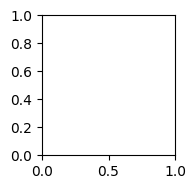

In [7]:
# Nombre d'images à afficher
n = 5

plt.figure(figsize=(10, 4))
for i in range(n):
    # Image originale
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_train_clean[i].numpy())
    plt.title("Originale")
    plt.axis("off")

    # Image bruitée correspondante
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_train_noisy[i].numpy())
    plt.title("Bruitée")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [16]:
# Valeurs entre 0 et 1
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

TypeError: '>=' not supported between instances of '_PrefetchDataset' and 'float'

# 4. Construction de l’autoencodeur convolutif

C’est le cœur du livrable.
Tu construis un modèle Keras basé sur des couches de convolution et de max pooling pour encoder, puis des couches de convolution transpose ou upsampling pour décoder.

In [17]:
from tensorflow.keras import layers, models

input_img = layers.Input(shape=(32, 32, 3))

# Encodeur
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

# Décodeur
x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
decoded = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

# ---- Compilation du modèle ----
autoencoder = models.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,347 (52.14 KB)

 Trainable params: 13,347 (52.14 KB)

 Non-trainable params: 0 (0.00 B)

# 5. Entraînement du modèle

In [18]:
history = autoencoder.fit(
    x_train_noisy, x_train_clean,
    epochs=20,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test_clean)
)


ValueError: When providing `x` as a tf.data.Dataset, `y` should not be passed. Instead, the targets should be included as part of the tf.data.Dataset.

In [37]:
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.show()


NameError: name 'history' is not defined

# 6. Évaluation : comparaison avant / après débruitage

Affiche des images bruitées, nettoyées, et originales pour montrer la performance du modèle.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step


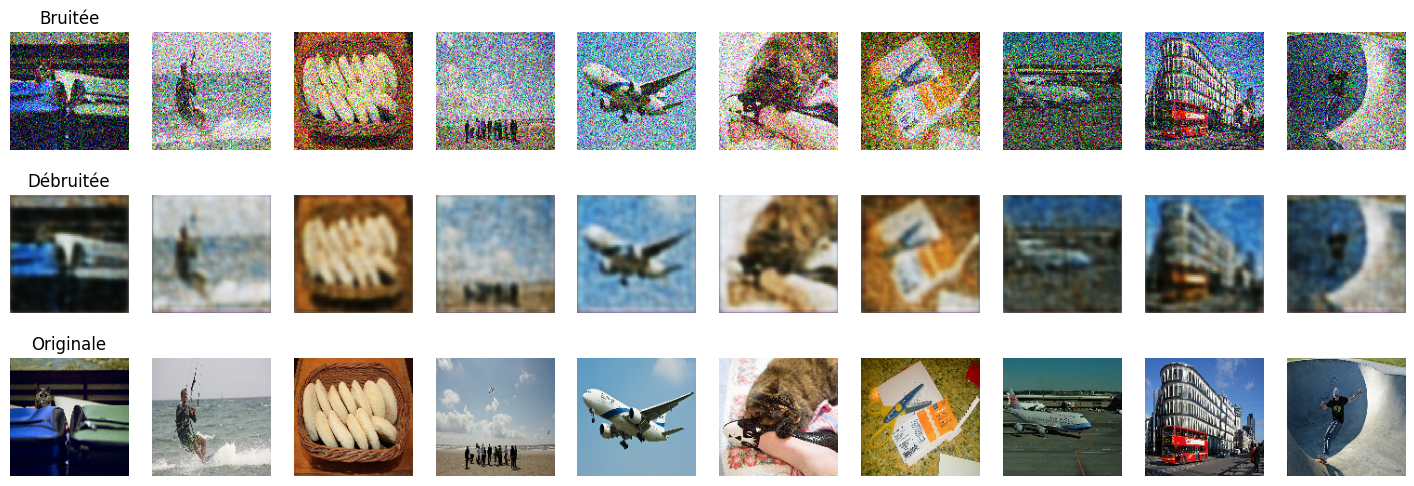

In [28]:
decoded_imgs = autoencoder.predict(x_test_noisy)

n = 10
plt.figure(figsize=(18, 6))
for i in range(n):
    # Image bruitée
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test_noisy[i])
    plt.axis("off")

    # Image restaurée
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(decoded_imgs[i])
    plt.axis("off")

    # Image originale
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(x_test_clean[i])
    plt.axis("off")
plt.show()


# 7. Étude de cas

Choisis une image précise du dataset et montre :

Son état initial (bruitée)

Le résultat du modèle (dénuée du bruit)

L’analyse qualitative (ce qui a été bien restauré ou perdu)

Tu peux aussi quantifier la qualité du débruitage avec des métriques :

In [20]:
from skimage.metrics import peak_signal_noise_ratio as psnr

score = psnr(x_test_clean[0], decoded_imgs[0])
print("PSNR de l’image :", score)


TypeError: '_PrefetchDataset' object is not subscriptable